In [1]:
from time import time

from cplex import Cplex
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
    MonodromyLPGate,
)
from hetero_isas.monodromy_lp.lp_constraints.docplex_constraints import (
    DocplexConstraints,
)
from hetero_isas.monodromy_lp.isa import ISAHandler
from qiskit.circuit.library import CXGate, CZGate, SwapGate, iSwapGate
from qiskit.quantum_info.random import random_unitary
from tqdm.notebook import tqdm

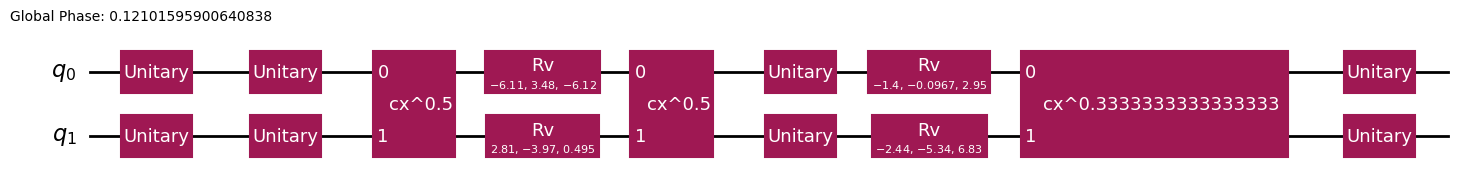

In [2]:
# target_u = SwapGate()
target_u = random_unitary(4).to_matrix()
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
        # CXGate().power(1 / 4),
        # CXGate().power(1 / 5),
    ],
    [1.0, 1 / 2, 1 / 3],  # , 1 / 4, 1 / 5],
    ["cx,", "sq[2]cx", "sq[3]cx"],  # , "sq[4]cx", "sq[5]cx"],
)

# isa_handler = ISAHandler(
#     [
#         iSwapGate(),
#         iSwapGate().power(1 / 2),
#         iSwapGate().power(1 / 3),
#     ],
#     [1.0, 1 / 2, 1 / 3],
#     ["is,", "sq[2]is", "sq[3]is"],
# )

decomposer = MonodromyLPDecomposer(isa_handler)
qc, result = decomposer(target_u, debugging=True)
qc.draw("mpl")

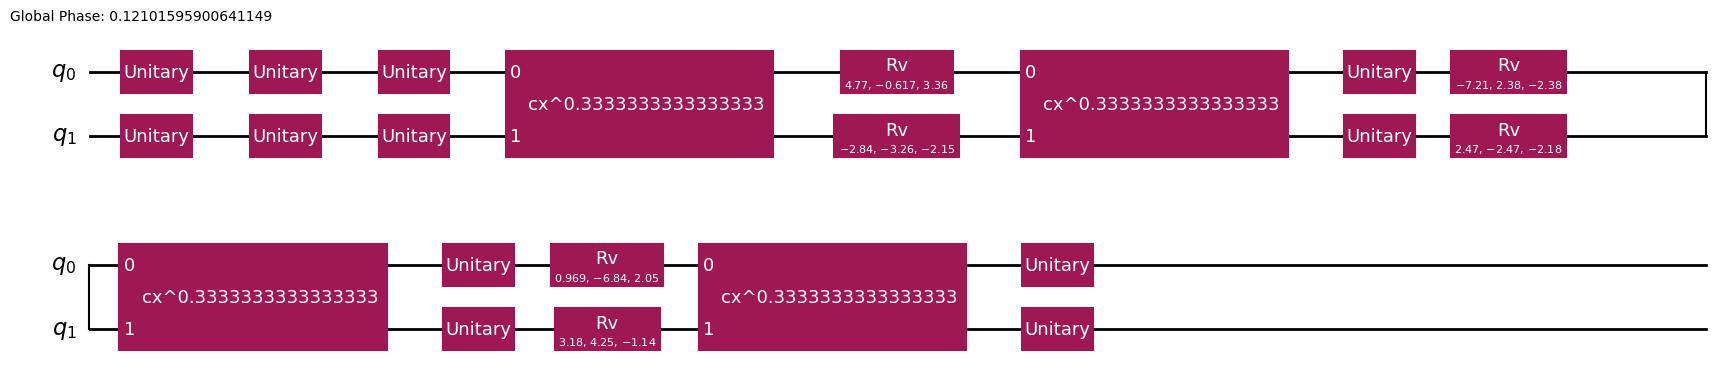

In [3]:
decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=False)
qc, result = decomposer(target_u, debugging=True)
qc.draw("mpl")

In [4]:
gate_sequence = next(isa_handler.isa._unordered_padded_sequence())

start_time = time()
model = DocplexConstraints(gate_sequence, 6)
model.model.parameters.preprocessing.presolve = 1
print("build model", time() - start_time)
model.model.print_information()

build model 0.02228569984436035
Model: docplex_model2
 - number of variables: 58
   - binary=25, integer=0, continuous=33
 - number of constraints: 458
   - linear=386, indicator=72
 - parameters:
     parameters.threads = 1
     parameters.barrier.algorithm = 3
     parameters.emphasis.mip = 1
     parameters.mip.cuts.nodecuts = 2
     parameters.mip.limits.cutpasses = -1
     parameters.mip.strategy.branch = 1
     parameters.mip.strategy.heuristicfreq = -1
     parameters.mip.strategy.nodeselect = 2
     parameters.mip.strategy.rinsheur = -1
     parameters.preprocessing.dual = 1
     parameters.preprocessing.folding = 0
     parameters.preprocessing.symmetry = 0
 - objective: minimize
 - problem type is: MILP


In [5]:
warmup_target = MonodromyLPGate.from_unitary(random_unitary(4).to_matrix())
start_time = time()
model.attempt_solve(warmup_target)
print("warm start w/ random target", time() - start_time)

warm start w/ random target 0.013297080993652344


In [6]:
target = MonodromyLPGate.from_unitary(target_u)
start_time = time()
x, y = model.attempt_solve(target)  # , log_output=True)
print("set target and solve", time() - start_time)
print(model.model.solve_details)
print([xi.name for xi in x])
print(y)

set target and solve 0.00990605354309082
status  = integer optimal solution
time    = 0.00709701 s.
problem = MILP
gap     = 0%

['sq[3]cx', 'sq[3]cx', 'sq[3]cx', 'sq[3]cx']
[array([0., 0., 0.]), (np.float64(0.0), np.float64(0.0), np.float64(0.0)), [0.16666666666666663, 0.04601658813124676, -0.04601658813124676], [0.24999999999999994, -0.014420218095117121, -0.037316745202086554], [0.31925474302517176, 0.0689131152382162, -0.12065007853541987]]


In [7]:
def random_bench(X, use_tqdm=False):
    model = DocplexConstraints(gate_sequence, 6)
    r = tqdm(range(X)) if use_tqdm else range(X)
    for _ in r:
        target = MonodromyLPGate.from_unitary(random_unitary(4).to_matrix())
        assert model.attempt_solve(target)


random_bench(500, True)

  0%|          | 0/500 [00:00<?, ?it/s]

In [8]:
# %reload_ext snakeviz
# import cProfile

# cProfile.run(
#     "random_bench(1)",
#     # "model.attempt_lp_solve()",
#     "../../../docs/profile_timings/model.prof",
# )

In [9]:
# # model.model.export_as_lp("../../../docs/profile_timings")
# model.model.export_as_mps("../../../docs/profile_timings")

# cpx = model.model.get_engine().get_cplex()
# status = cpx.parameters.tune_problem_set(
#     ["/home/evm9/dev_workspace/docs/profile_timings/docplex_model1.mps"]
# )
# if status == cpx.parameters.tuning_status.completed:
#     print("tuned parameters:")
#     for param, value in cpx.parameters.get_changed():
#         print("{0}: {1}".format(repr(param), value))
# else:
#     print("tuning status was: {0}".format(cpx.parameters.tuning_status[status]))